# 1.Data Loading & Exploration

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Data
df = pd.read_csv('/content/sample_data/Housing.csv')

In [3]:
# First 10 Rows
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
# No. of rows and columns
print('Rows:',df.shape[0])
print('Columns:',df.shape[1])

Rows: 545
Columns: 13


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
# Missing Values
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [8]:
# Target column and features
target="price"
features=[col for col in df.columns if col!=target]

print("Target column:", target)
print("Features:", features)

Target column: price
Features: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [9]:
# Target Value
y = df.iloc[:,0]
y

,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000
...,...
540,1820000
541,1767150
542,1750000
543,1750000


In [10]:
# Features
X = df.iloc[:,1:]
X

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,2910,3,1,1,no,no,no,no,no,0,no,furnished


# 2.Data Cleaning


In [11]:
# Check Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [12]:
# Remove duplicates if present
df.drop_duplicates(inplace=True)

In [13]:
# Check missing values
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


# We don't have any missing values in this data set

In [14]:
# Convert Binary categorical variables into numerical values, where 'yes' was mapped to 1 and 'no' to 0
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_cols:
    df[col] = df[col].map({'yes':1, 'no':0})

In [15]:
# One-Hot Encode for 'furnishingstatus' Categorical Column
df = pd.get_dummies(
    df,
    columns=['furnishingstatus'],
    drop_first=True
).astype(int)

In [16]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0
5,10850000,7500,3,3,1,1,0,1,0,1,2,1,1,0
6,10150000,8580,4,3,4,1,0,0,0,1,2,1,1,0
7,10150000,16200,5,3,2,1,0,0,0,0,0,0,0,1
8,9870000,8100,4,1,2,1,1,1,0,1,2,1,0,0
9,9800000,5750,3,2,4,1,1,0,0,1,1,1,0,1


In [17]:
# The columns that are meaningful for predicting price
print("Meaningful Columns: ", df.iloc[:,1:].columns)

Meaningful Columns:  Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')


In [18]:
#Final Look of the Data
print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
df.head(10)

Shape: (545, 14)

Missing Values:
price                              0
area                               0
bedrooms                           0
bathrooms                          0
stories                            0
mainroad                           0
guestroom                          0
basement                           0
hotwaterheating                    0
airconditioning                    0
parking                            0
prefarea                           0
furnishingstatus_semi-furnished    0
furnishingstatus_unfurnished       0
dtype: int64

Duplicates: 0


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0
5,10850000,7500,3,3,1,1,0,1,0,1,2,1,1,0
6,10150000,8580,4,3,4,1,0,0,0,1,2,1,1,0
7,10150000,16200,5,3,2,1,0,0,0,0,0,0,0,1
8,9870000,8100,4,1,2,1,1,1,0,1,2,1,0,0
9,9800000,5750,3,2,4,1,1,0,0,1,1,1,0,1


#  3.Model Building

In [19]:
# X = Input Features
X = df.iloc[:,1:]
# y = Target Variable (Price)
y = df.iloc[:,0]

In [20]:
# Trai-Test Split(80/20)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
print("Shape of Training data:",X_train.shape)
print("Shape of Testing data:",X_test.shape)

Shape of Training data: (436, 13)
Shape of Testing data: (109, 13)


In [22]:
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
# Linear Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_scaled,y_train)

LinearRegression()

In [24]:
# Parameters
print("Coefficient:", lr.coef_)
print("Intercept:", lr.intercept_)

Coefficient: [ 519552.41633999   57349.55941862  521879.02774805  349251.43890557
  128498.62821472   88768.66768638  187067.80321388  149862.70299085
  365157.39385091  192005.95366749  266656.3519933   -62837.32186493
 -192015.91798221]
Intercept: 4706527.385321101


In [25]:
y_pred_lr = lr.predict(X_test_scaled)

In [26]:
# Evaluation
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
print("MAE_lr : ", mean_absolute_error(y_test, y_pred_lr))
print("RMSE_lr : ", root_mean_squared_error(y_test, y_pred_lr))
print("R2Score_lr : ", r2_score(y_test, y_pred_lr))

MAE_lr :  970043.4039201642
RMSE_lr :  1324506.9600914402
R2Score_lr :  0.6529242642153176


In [27]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=200,random_state=42)
rf.fit(X_train,y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [28]:
y_pred_rf = rf.predict(X_test)

In [29]:
# Evaluation
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
print("MAE_rf : ", mean_absolute_error(y_test, y_pred_rf))
print("RMSE_rf : ", root_mean_squared_error(y_test, y_pred_rf))
print("R2Score_rf : ", r2_score(y_test, y_pred_rf))

MAE_rf :  1014947.3230122325
RMSE_rf :  1399769.443949671
R2Score_rf :  0.6123598247296523


In [30]:
# Model Comparison
comparsion=pd.DataFrame({
    'Model':['Linear Regression','Random Forest'],
    'MAE':[mean_absolute_error(y_test, y_pred_lr), mean_absolute_error(y_test, y_pred_rf)],
    'RMSE':[root_mean_squared_error(y_test, y_pred_lr),root_mean_squared_error(y_test, y_pred_rf)],
    'R2 Score':[r2_score(y_test, y_pred_lr),r2_score(y_test, y_pred_rf)]
})
comparsion

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.014947e+06,1.399769e+06,0.612360


# Comparison Between Linear Regression and Random Forest Regressor
1. The performance of Linear Regression and Random Forest Regressor was compared using MAE, RMSE, and R² Score

2. Linear Regression achieved a lower MAE (970043) and RMSE (1324507) than Random Forest Regressor indicating more accurate predictions.Linear Regression obtained a higher R² Score (0.653) compared to Random Forest (0.612) meaning it explained a greater proportion of the variation in house prices

3. Based on these evaluation metrics, Linear Regression performed better on this dataset and was selected as the preferred model for house price prediction

# 4.Visualization

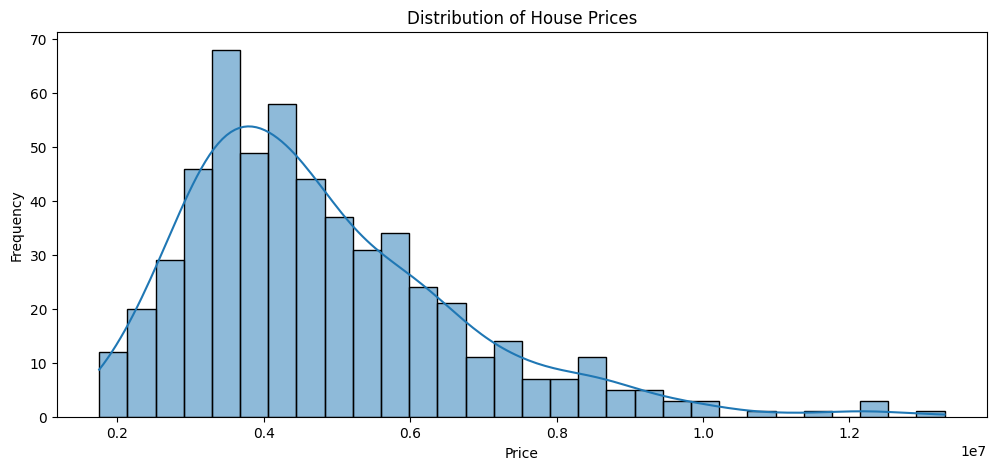

In [54]:
# Histogram of House prices
plt.figure(figsize=(12,5))
sns.histplot(df['price'],bins=30,kde=True)

plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

1. House prices are right-skewed
2. Most houses are priced between 3 million and 6 million
3. There are a few expensive houses above 10 million, which act as outliers
4. The dataset does not follow a perfectly normal distribution

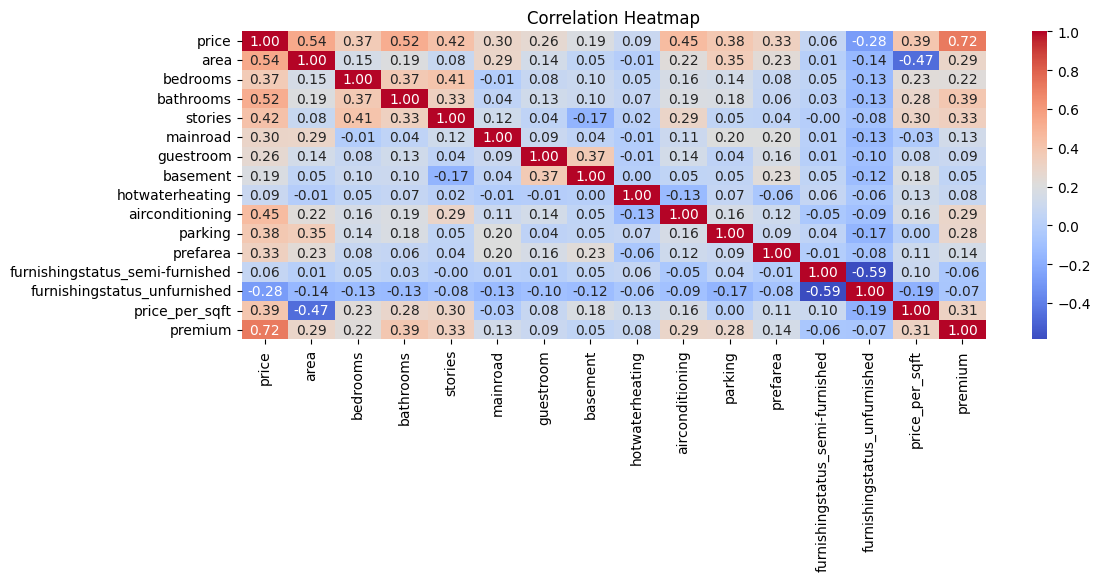

In [56]:
# Correlation Heatmap
plt.figure(figsize=(12,4))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

# Features relate most strongly to price
1. area-0.54
2. bathrooms-0.52
3. airconditioning-0.45
4. stories-0.42
5. parking-0.38
6. bedrooms-0.37

Here we chose features according to our threshold, Like here I used 0.35. So if threshold changes then no. of important features will also change.

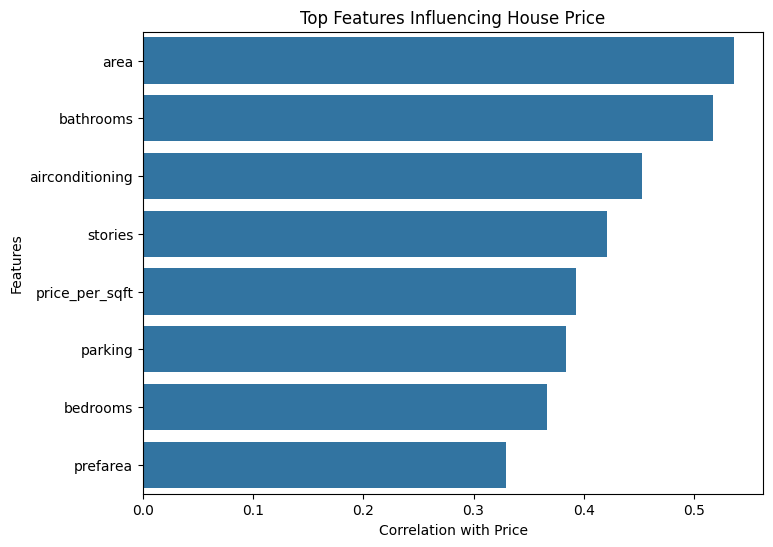

In [41]:
corr_price = df.corr()['price'].drop('price')

corr_price = corr_price.sort_values(ascending=False)

plt.figure(figsize=(8,6))

sns.barplot(
    x=corr_price.values[:8],
    y=corr_price.index[:8]
)

plt.title('Top Features Influencing House Price')
plt.xlabel('Correlation with Price')
plt.ylabel('Features')

plt.show()

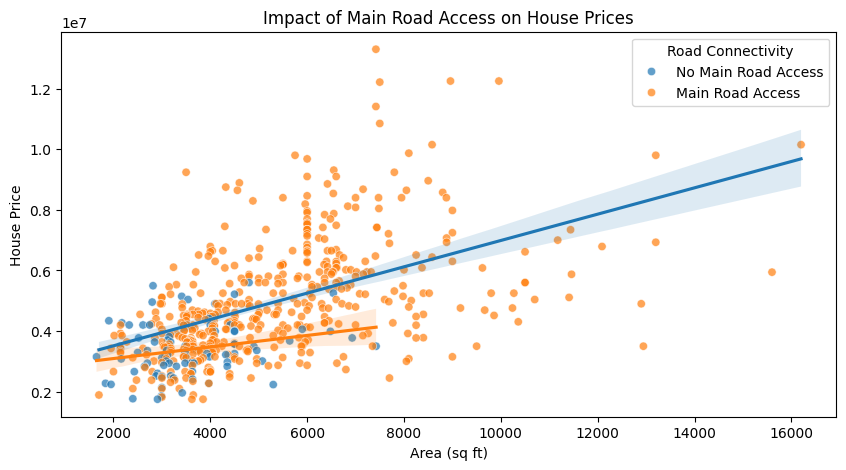

In [57]:
plt.figure(figsize=(10,5))

ax = sns.scatterplot(
    data=df,
    x='area',
    y='price',
    hue='mainroad',
    alpha=0.7
)

sns.regplot(
    data=df[df['mainroad']==1],
    x='area',
    y='price',
    scatter=False
)

sns.regplot(
    data=df[df['mainroad']==0],
    x='area',
    y='price',
    scatter=False
)

handles, labels = ax.get_legend_handles_labels()

ax.legend(
    handles,
    ['No Main Road Access', 'Main Road Access'],
    title='Road Connectivity'
)

plt.title('Impact of Main Road Access on House Prices')
plt.xlabel('Area (sq ft)')
plt.ylabel('House Price')

plt.show()

- As the area of a house increases, its price generally increases. This confirms that area is one of the most important factors affecting house prices.
- Houses connected to a main road tend to have higher prices than houses of similar size without main-road access.
- Most luxury and high-value properties in the dataset have direct main-road access, indicating that accessibility is a key characteristic of premium properties.
- Larger residential properties are more commonly located in areas with main-road connectivity.

 # 5.Insights & Summary

## 1. Which features influence house price the most?

- The area of the house was found to have the strongest influence on its price.
- Other important factors included the number of bathrooms, parking space, availability of air conditioning, and the number of stories.
- The feature importance plot showed that these variables contributed the most to predicting house prices.
- The correlation heatmap also indicated a strong relationship between these features and house prices.

## 2. How accurate was the model (in plain terms)?

- Two models, Linear Regression and Random Forest Regression, were used to predict house prices.
- Linear Regression performed slightly better than Random Forest Regression.
- It achieved an R² score of approximately 0.652924, which means the model was able to explain around 65% of the variation in house prices.
- The model provided reasonably accurate predictions and captured the major factors affecting house prices.

## 3. What surprised you in the data?
- I thought the size of the house would be the only major factor, but I found that road connectivity, number of bathrooms, parking availability, and air conditioning also had a significant impact on house prices.
- I was surprised to see such a large difference in prices between houses that had a similar area.
- I noticed that some houses with a moderate area were priced higher than larger houses, which shows that location and amenities matter a lot.
- I expected Random Forest to perform better, but Linear Regression actually gave better results on this dataset.

## 4. One recommendation for a real estate business based on your findings
Real estate businesses should focus not only on the size of a property but also on features that add value, such as main-road access, adequate parking, air conditioning, and additional bathrooms. The analysis showed that houses with better connectivity and amenities often achieved higher prices, even when their area was similar to other properties. Therefore, developers and sellers should highlight these features in marketing campaigns and prioritize them when planning new residential projects to maximize property value and attract more buyers.